# Forward Neural Network

This notebook will go thorugh the process of building and training a forward network with 6 input features (ax, ay, az, gx, gy, gz), 4 output classes (walking, running, jumping and stairs), two hidden layers. We will experiment with 10 and 50 neurons per hidden layer, as well as investigate benefits of normalization and plotting of accuracy/loss for train/validation.

Let's start by importing necessary libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow import keras

# For reproducibility
import random
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

2025-10-12 22:43:50.435056: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Next, we define an array of objects to easily access our data paths:

In [2]:
classes = ['jumping', 'walking', 'running', 'stairs']
categories = ["train", "valid", "test"]

In [3]:
train_df = pd.read_pickle('../pickles/combined/train_df.pkl')
test_df = pd.read_pickle('../pickles/combined/test_df.pkl')
valid_df = pd.read_pickle('../pickles/combined/valid_df.pkl')

print("Train shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())

print("Test shape:", test_df.shape)
print("Columns:", test_df.columns.tolist())

print("Valid shape:", valid_df.shape)
print("Columns:", valid_df.columns.tolist())

X_train = train_df.drop('class', axis=1)
y_train = train_df['class']

X_test = test_df.drop('class', axis=1)
y_test = test_df['class']

X_valid = test_df.drop('class', axis=1)
y_valid = test_df['class']

Train shape: (23566, 7)
Columns: ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'class']
Test shape: (5138, 7)
Columns: ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'class']
Valid shape: (8997, 7)
Columns: ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'class']


We will encode labels so Keras can use them:

In [4]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
y_valid_enc  = le.transform(y_valid)

Next we will normalize features using MinMaxScaler. Normalization of inputs helps training stability and speed because gradients become well conditioned.

In [5]:
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_valid_scaled = scaler.transform(X_valid)

## Building feedforward neural nets (2 hidden layers)

A feedforward neural network (FFNN) is a stack of layers where data flows from inputs to outputs without cycles. Each hidden layer is a set of neurons; each neuron computes a weighted sum of its inputs, applies an activation function (ReLU, sigmoid, etc.), and passes the output forward. The final layer produces class scores; for multi-class classification we use a softmax activation so outputs form a probability distribution over the 4 classes. Training uses backpropagation: compute loss (how wrong the model is), compute gradients, and update weights via an optimizer (commonly Adam). Key hyperparameters: number of layers, neurons per layer, activation functions, batch size, learning rate, and number of epochs.

An epoch represents one complete pass through the entire training dataset during the training process of a neural network. In each epoch, the model adjusts its internal parameters (weights and biases) in an attempt to minimize the prediction error. Training for multiple epochs allows the model to learn patterns in the data gradually, improving its performance over time.

The loss is a measure of how far the model’s predictions are from the actual target values. It quantifies the model’s error.

The EarlyStopping callback is a technique used to prevent overfitting and save training time. It monitors a chosen metric, usually the validation loss, and stops the training process automatically if the metric stops improving for a given number of epochs (defined by the patience parameter). This ensures that the model does not continue training once it has reached its optimal performance.

In this lab, we set the number of epochs to 100 for both the 10-neuron and 50-neuron models. However, since EarlyStopping is used, the training process will stop automatically before reaching 100 epochs if the model’s validation loss stops improving. This means each model may train for a different number of epochs depending on how quickly it converges. The actual number of epochs needed can be determined by observing when the training and validation curves flatten out, indicating that the model has finished learning effectively.

We define a function that builds the model

In [6]:
def build_ffnn(num_neurons=10, input_dim=None, num_classes=4, lr=1e-3):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(num_neurons, activation="relu"),
        keras.layers.Dense(num_neurons, activation="relu"),
        keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

We define a function that trains and evaluate our model:

In [7]:
def train_and_evaluate(Xtr, Xv, ytr, yv, neurons, model_name_suffix, epochs=100, batch_size=32):
    model = build_ffnn(num_neurons=neurons, input_dim=Xtr.shape[1], num_classes=len(classes))
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
    ]
    history = model.fit(Xtr, ytr,
                        validation_data=(Xv, yv),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=callbacks,
                        verbose=2)
    return model, history

### 10 neurons per hidden layer

In [8]:
model_10_scaled, hist_10_scaled = train_and_evaluate(X_train_scaled, X_valid_scaled, y_train_enc, y_valid_enc, neurons=10, model_name_suffix="10_scaled")

Epoch 1/100
737/737 - 1s - loss: 1.2734 - accuracy: 0.3724 - val_loss: 1.1947 - val_accuracy: 0.3630 - lr: 0.0010 - 1s/epoch - 2ms/step
Epoch 2/100
737/737 - 1s - loss: 1.0435 - accuracy: 0.6108 - val_loss: 0.8460 - val_accuracy: 0.7036 - lr: 0.0010 - 639ms/epoch - 866us/step
Epoch 3/100
737/737 - 1s - loss: 0.7548 - accuracy: 0.7187 - val_loss: 0.5868 - val_accuracy: 0.7908 - lr: 0.0010 - 599ms/epoch - 812us/step
Epoch 4/100
737/737 - 1s - loss: 0.6302 - accuracy: 0.7732 - val_loss: 0.4994 - val_accuracy: 0.8221 - lr: 0.0010 - 591ms/epoch - 802us/step
Epoch 5/100
737/737 - 1s - loss: 0.5717 - accuracy: 0.7941 - val_loss: 0.4565 - val_accuracy: 0.8433 - lr: 0.0010 - 590ms/epoch - 801us/step
Epoch 6/100
737/737 - 1s - loss: 0.5363 - accuracy: 0.8077 - val_loss: 0.4225 - val_accuracy: 0.8533 - lr: 0.0010 - 590ms/epoch - 801us/step
Epoch 7/100
737/737 - 1s - loss: 0.5122 - accuracy: 0.8147 - val_loss: 0.4037 - val_accuracy: 0.8558 - lr: 0.0010 - 594ms/epoch - 806us/step
Epoch 8/100
737/73

### How many epochs where needed?

From epoch 58 to 66, both the training loss (loss) and validation loss (val_loss) have become very stable. This tells us that the model has essentially stopped improving. 

The 10-neuron model reached its optimal performance after approximately 60 epochs.

### 50 neurons per hidden layer

In [9]:
model_50_scaled, hist_50_scaled = train_and_evaluate(X_train_scaled, X_valid_scaled, y_train_enc, y_valid_enc, neurons=50, model_name_suffix="50_scaled")

Epoch 1/100
737/737 - 1s - loss: 0.9726 - accuracy: 0.6275 - val_loss: 0.5317 - val_accuracy: 0.8258 - lr: 0.0010 - 1s/epoch - 2ms/step
Epoch 2/100
737/737 - 1s - loss: 0.5513 - accuracy: 0.8079 - val_loss: 0.3624 - val_accuracy: 0.8739 - lr: 0.0010 - 641ms/epoch - 870us/step
Epoch 3/100
737/737 - 1s - loss: 0.4533 - accuracy: 0.8382 - val_loss: 0.3163 - val_accuracy: 0.8959 - lr: 0.0010 - 652ms/epoch - 885us/step
Epoch 4/100
737/737 - 1s - loss: 0.4066 - accuracy: 0.8580 - val_loss: 0.2959 - val_accuracy: 0.9017 - lr: 0.0010 - 647ms/epoch - 878us/step
Epoch 5/100
737/737 - 1s - loss: 0.3781 - accuracy: 0.8692 - val_loss: 0.2765 - val_accuracy: 0.9064 - lr: 0.0010 - 642ms/epoch - 871us/step
Epoch 6/100
737/737 - 1s - loss: 0.3571 - accuracy: 0.8744 - val_loss: 0.2664 - val_accuracy: 0.9109 - lr: 0.0010 - 645ms/epoch - 876us/step
Epoch 7/100
737/737 - 1s - loss: 0.3399 - accuracy: 0.8820 - val_loss: 0.2452 - val_accuracy: 0.9206 - lr: 0.0010 - 643ms/epoch - 873us/step
Epoch 8/100
737/73

### How many epochs where needed?

The model finished learning most of what it could by around epoch 30–32. After that, improvements are tiny or inconsistent.

So, the 50-neuron model effectively needed around 30 epochs to reach its optimal performance.

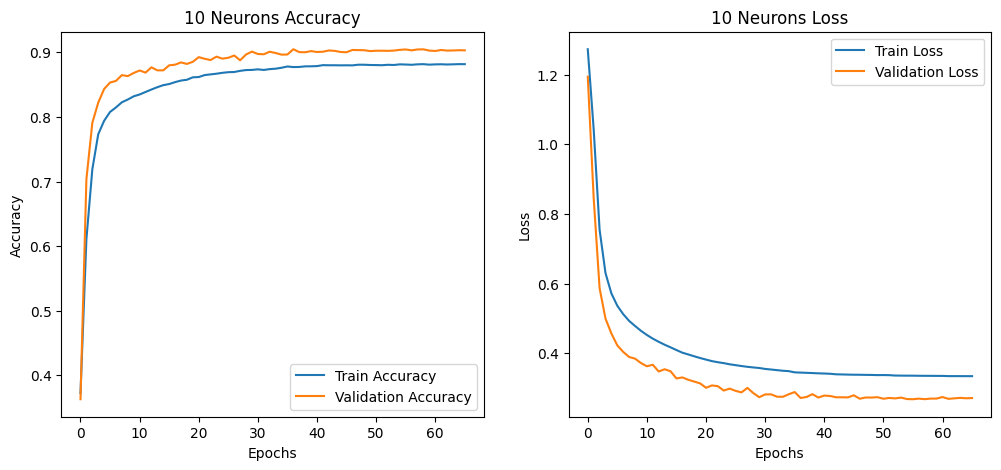

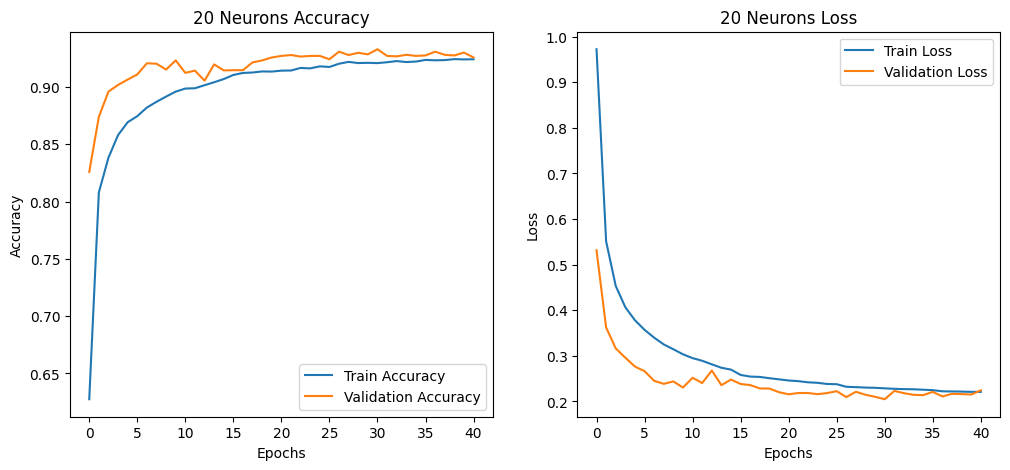

In [10]:
def plot_training_history(history, model_name="Model"):
    # Plot Accuracy
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

# Plot both models
plot_training_history(hist_10_scaled, model_name="10 Neurons")
plot_training_history(hist_50_scaled, model_name="20 Neurons")

Both models show similar trends, but the 50-neuron model’s validation curves are slightly higher and lower in loss, respectively. Plus, the training and validation curves are close together on the the 50-neuron model’s.

This means the 50-neuron network learned more complex patterns without overfitting, giving it a small but consistent performance advantage.

## Evaluating the model on the test set

In [11]:
test_loss, test_accuracy = model_50_scaled.evaluate(X_test_scaled, y_test_enc, verbose=2)

train_loss = hist_50_scaled.history['loss'][-1]
train_accuracy = hist_50_scaled.history['accuracy'][-1]
val_loss = hist_50_scaled.history['val_loss'][-1]
val_accuracy = hist_50_scaled.history['val_accuracy'][-1]

print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

161/161 - 0s - loss: 0.2049 - accuracy: 0.9329 - 165ms/epoch - 1ms/step
Training Loss: 0.2210
Training Accuracy: 0.9241
Validation Loss: 0.2244
Validation Accuracy: 0.9257
Test Loss: 0.2049
Test Accuracy: 0.9329


The model shows consistent performance across all sets, with training accuracy at 92.41%, validation at 92.57%, and test at 93.29%. The similar loss and accuracy values indicate that the model generalizes well without overfitting, performing reliably on unseen data.

## Difference between evaluate() and predict()

The evaluate() method is used to compute the model’s overall performance by returning the loss and metrics (like accuracy) for a given dataset. It does not provide individual predictions but summarizes the model’s performance numerically.

The predict() method, on the other hand, generates predicted outputs (such as class probabilities or labels) for each input sample. This method is used when we need to analyze specific predictions, such as when creating a confusion matrix or calculating custom metrics.

## Calculating and plotting the confusion matrix

Since the confusion matrix requires the actual predictions for each test sample, we will use predict()

Let's start with the 10-neurons model:

161/161 [==============================] - 0s 971us/step


<Figure size 400x400 with 0 Axes>

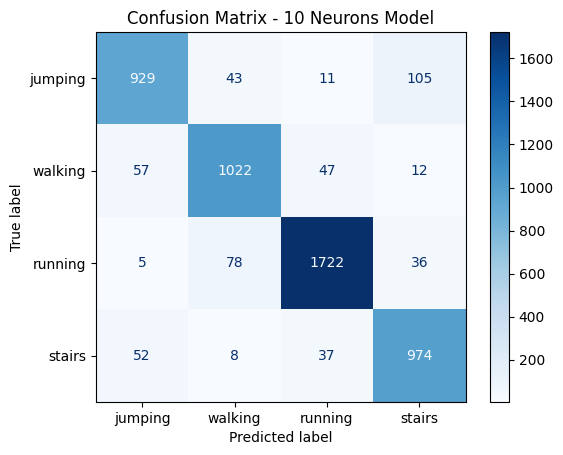

In [12]:
# Predict class probabilities
y_pred_probs = model_10_scaled.predict(X_test_scaled)

# Convert probabilities to class indices
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Plot confusion matrix
plt.figure(figsize=(4,4))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - 10 Neurons Model")
plt.show()

Next we focus on the 50-neurons model:

161/161 [==============================] - 0s 685us/step


<Figure size 400x400 with 0 Axes>

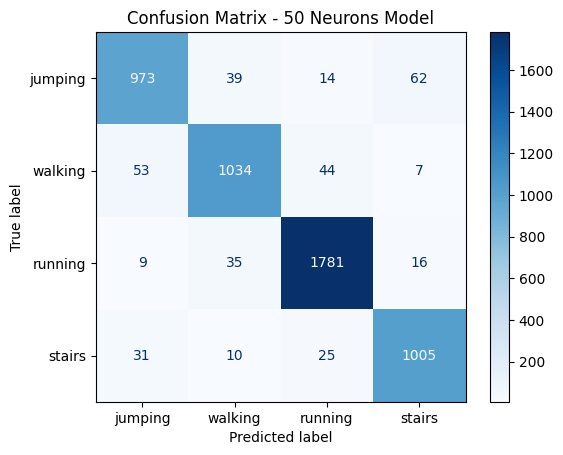

In [13]:
# Predict class probabilities
y_pred_probs = model_50_scaled.predict(X_test_scaled)

# Convert probabilities to class indices
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Plot confusion matrix
plt.figure(figsize=(4,4))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - 50 Neurons Model")
plt.show()

When comparing the confusion matrices of the 10-neuron and 50-neuron models, the overall differences are relatively small, indicating that both models perform similarly in classifying the test samples. In both cases, the class “running” achieved the highest accuracy, with approximately 1750 correct predictions, while the other three classes,“walking,” “jumping,” and “stairs”, each had around 1000 correct predictions. The 50-neuron model showed a slight improvement, correctly predicting roughly 50 more samples per class compared to the 10-neuron model. 

However, since the performance gap is small, the simpler 10-neuron model might still be preferred in situations where computational efficiency and faster training are more important than a minor accuracy gain.